In [1]:
import torch

In [2]:
from importlib.metadata import version
pkgs=[
    "matplotlib",
    "numpy",
    "tiktoken",
    "torch",
    "tensorflow"
]

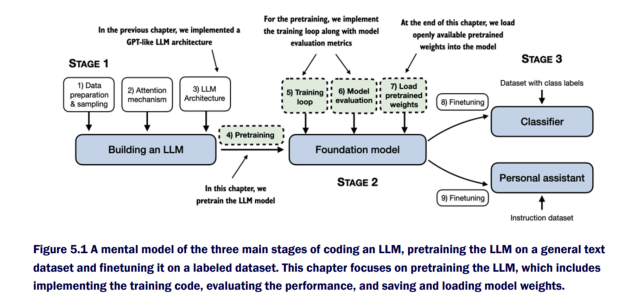

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.1.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### in the previous chapters, we implemented the data sampling, attention mechanism and coded the LLM architecture. The core focus of this chapter is to implement a training function and pretrain the LLM, as illustrated in Figure 5.1.

##### as illustrated in Figure 5.1, we will also learn about basic model evaluation techniques to measure the quality of the generated text, which is a requirement for optimizing the LLM during the training process. Moreover, we will discuss how to load pretrained weights,giving our LLM a solid starting point for finetuning in the upcoming chapte

##### WEIGHT PARAMETERS -> In the context of LLMs and other deep learning models, weights refer to the trainable parameters that the learning process adjusts. These weights are also known as weight parameters or simply parameters. In frameworks like PyTorch, these weights are stored in linear layers, for example, which we used to implement the multi-head attention module in chapter 3 and the GPTModel in chapter 4. After initializing a layer(new_layer = torch.nn.Linear(...)), we can access its weights through the .weight attribute, new_layer.weight. Additionally, for convenience, PyTorch allowsdirect access to all a model's trainable parameters, including weights and biases, through the method model.parameters(), which we will use later when implementing the model training.

### 5.1 Evaluating generative text models

##### We begin this chapter by setting up the LLM for text generation based on code from the previous chapter and discuss basic ways to evaluate the quality of the generated text in this section.

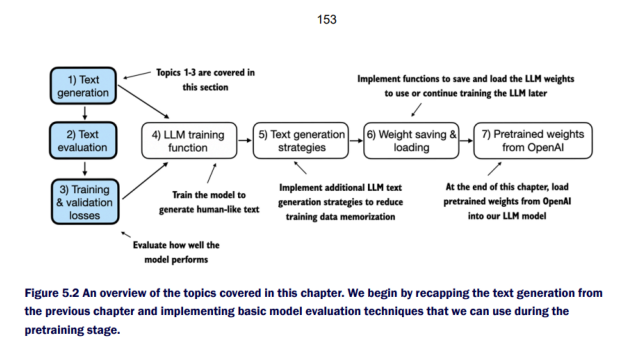

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.2.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### the next subsection recaps the text generation we set up at the end of the previous chapter before we dive into the text evaluation and calculation of the training and validation losses in the subsequent subsection

### 5.1.1 Using GPT to generate text

##### we set up the LLM and briefly recap the text generation process we implemented in previous chapter. we begin by initializing the GPT model that we will evaluate and train in this chapter, using the GPTModel class and GPT_CONFIG_124M dictionary from gpt arch chapter.

##### please note: the components.py in this chapter is the updated version of the components.py used in previous chapter, now it has all the other compoents that are require to run the gptmodel here

In [5]:
from components import GPTModel

In [6]:
GPT_CONFIG_124M = {
"vocab_size": 50257,
"context_length": 256, # We shorten the context length from 1024 to 256 tokens
"emb_dim": 768,
"n_heads": 12,
"n_layers": 12,
"drop_rate": 0.1, #
"qkv_bias": False
}


##### instantiate the gpt model

In [7]:
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (att): MaskedMultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (output_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (norm2): LayerNorm()
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (dropout_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (att): MaskedMultiHeadAtt

##### using the GPTmodel instance, we adopt the generate_text_simple function introduced  in the previous chapter and introduce two handy functions, text_to_token_ids and token_ids_to_text. these functions facilitate the conversion between text and token representations

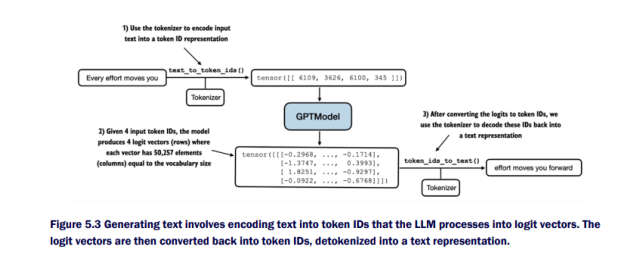

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.3.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### First, the tokenizer converts input text into a series of token IDs. Second, the model receives these token IDs and generates corresponding logits, which are vectors representing the probability distribution for each token in the vocabulary. third, these logits are converted back into token IDs, which the tokenizer decodes into human-readable text, completing the cycle from textual input to textualoutput.

##### utility functions for text to token ID conversion

In [9]:
import tiktoken
from components import generate_text_simple

def text_to_token_ids(text,tokenizer):
    encoded=tokenizer.encode(text,allowed_special={'<|endoftext|>'})
    encoded_tensor=torch.tensor(encoded).unsqueeze(0) #we convert the list above to pytorch tensor cause the model expects tensor(adds batch dimension)
    return encoded_tensor

def token_ids_to_text(token_ids,tokenizer):
    flat=token_ids.squeeze(0) 
    return tokenizer.decode(flat.tolist()) #needs a normal Python list.

start_context="Every effort moves you"
tokenizer=tiktoken.get_encoding("gpt2")

token_ids=generate_text_simple(
    model=model,
    input_tokens=text_to_token_ids(start_context,tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("output  text:\n ",token_ids_to_text(token_ids,tokenizer))

output  text:
  Every effort moves you rentingetic wasnم refres RexMeCHicular stren


##### it's clear the model isn't yet producing coherent text because it hasn't undergone training.

##### To define what makes text "coherent" or "high quality," we have to implement a numerical method to evaluate the generated content. This approach will enable us to monitor and enhance the model's performance throughout its training process.

##### the following section introduces how we calculate a loss metric for the generated outputs. This loss serves as a progress and success indicator of the training progress. Furthermore, in subsequent chapters on finetuning LLMs, we will review additional methodologies for assessing model quality.

### 5.1.2 Calculating the text generation loss : cross entropy and perplexity

##### now , we explore techniques for numerically assessing text quality generated during training by calculating a so-called text generation loss. We go over this topic step-by-step with a practical example to make the concepts clear and applicable, beginning with a short recap of how the data is loaded from chapter 2 and how the text is generated via the generate_text_simple function from chapter 4

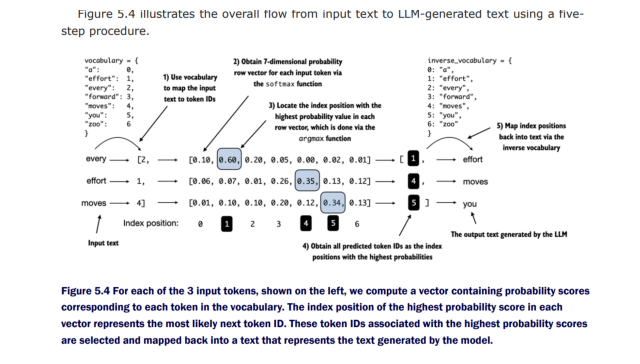

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.4.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### The text generation process in Figure 5.4 outlines what the generate_text_simple function from chapter 4 does internally. We need to perform these same initial steps before we can compute a loss that measures the generated text quality later in this section. Figure 5.4 outlines the text generation process with a small 7-token vocabulary to fit this image on a single page. However, our GPTModel works with a much larger vocabulary consisting of 50,257 words; hence, the token IDs in the following codes will range from 0 to 50,256 rather than 0 to 6.


##### Also, Figure 5.4 only shows a single text example ("every effort moves") for simplicity. In the following hands-on code example that implements the steps in Figure 5.4, we will work with two input examples ("every effort moves" and "I really like") as inputs for the GPT model: Consider the two input examples, which have already been mapped to token IDs,corresponding to step 1 in Figure 5.4:

In [11]:
inputs=torch.tensor([[16833, 3626, 6100],   #["Every effort moves,
                    [40, 1107, 588]]) #        I really like"]
#matching these inputs 'the target' contain the token ids we aim for the model to produce
targets = torch.tensor([[3626, 6100, 345 ], # [" effort moves you",
[107, 588, 11311]]) # " really like chocolate"]

##### targets are the inputs but shifted one position forward, a concept we covered chapter 2 during the implementation of the data loader. This shifting strategy is crucial for teaching the model to predict the next token in a sequence.


##### When we feed the inputs into the model to calculate logit vectors for the two input examples, each comprising three tokens, and apply the softmax function to transform these logit values into probability scores, which corresponds to step 2 in Figure 5.4:

In [12]:
with torch.no_grad(): #disable gradient tracking since we are not training, yet
    logits=model(inputs)
probas= torch.softmax(logits,dim=-1)
print(probas.shape)

torch.Size([2, 3, 50257])


##### the first number, 2, corresponds to the two examples (rows) in the inputs, also known as batch size. The second number, 3, corresponds to the number of tokens in each input(row). Finally, the last number corresponds to the embedding dimensionality, which is determined by the vocabulary size, as discussed in previous chapters.

##### following the conversion from logits to probabilities via the softmax function, the generate_text_simple function from chapter 4 then converts the resulting probability scores back into text, as illustrated in steps 3-5 in Figure 5.4

##### we can implement steps 3 and 4 by applying the argmax function to the probability scores to obtain the corresponding token IDs:

In [13]:
token_ids=torch.argmax(probas,dim=-1,keepdim=True)
print("token ids:\n", token_ids)
#here we are basically choosing tokens with highest probablites, each token choses 1, so since we have 2 sentence, ech with3 tokens, we will have 3 for first and3 for second inpt,all together 6 probab with higest value ie predicted token.

token ids:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


##### Finally, step 5 converts the token IDs back into text

In [14]:
print(f"target batch 1:{token_ids_to_text(targets[0],tokenizer)}")
print(f"output batch 1:{token_ids_to_text(token_ids[0].flatten(),tokenizer)}")

target batch 1: effort moves you
output batch 1: Armed heNetflix


##### what we did above was took the predicted tokens and convert both of them into the text to see what it predicted

##### The model produces random text that is different from the target text because it has not been trained yet.

##### we now evaluate the performance of the model's generated text numerically via a so-called loss as illustrated in Figure 5.4.  this is useful for measuring the quality of the generated text, but it's also a building block for implementing the training function later, which we use to update the model's weight to improve the generated tex

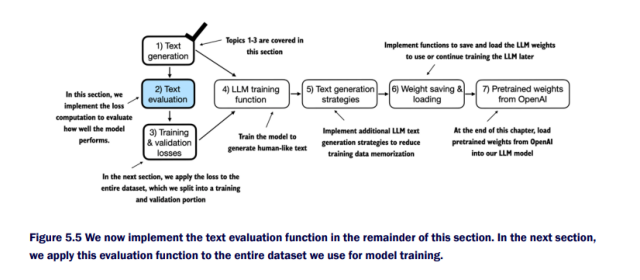

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.5.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### part of the text evaluation process that we implement in the remainder of this section, as shown in Figure 5.5, is to measure "how far" the generated tokens are from the correct  predictions (targets). The training function we implement later in this chapter will use this information to adjust the model weights to generate text that is more similar to (or ideally matches) the target text

##### the model training aims to increase the softmax probability in the index positions corresponding to the correct target token IDs, as illustrated in Figure 5.6. This softmax probability is also used in the evaluation metric we are implementing in the remainder of this section to numerically assess the model's generated outputs: the higher the probability in the correct positions, the better.


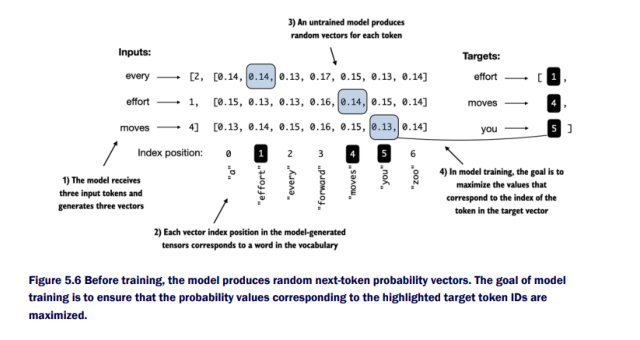

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.6.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

#####  figure 5.6 displays the softmax probabilities for a compact 7-token vocabulary to fit everything into a single figure. This implies that the starting random values will hover around 1/7, which equals approximately 0.14.However, the vocabulary we are using for our GPT-2 model has 50,257 tokens, so most of the initial probabilities will hover around 0.00002 via 1/50,257.For each of the two input texts, we can print the initial softmax probability scorescorresponding to the target tokens via the following code:

In [17]:
probas

tensor([[[1.8849e-05, 1.5172e-05, 1.1687e-05,  ..., 2.2409e-05,
          6.9776e-06, 1.8776e-05],
         [9.1569e-06, 1.0062e-05, 7.8786e-06,  ..., 2.9090e-05,
          6.0103e-06, 1.3571e-05],
         [2.9877e-05, 8.8507e-06, 1.5741e-05,  ..., 3.5456e-05,
          1.4094e-05, 1.3526e-05]],

        [[1.2561e-05, 2.0537e-05, 1.4332e-05,  ..., 1.0389e-05,
          3.4784e-05, 1.4239e-05],
         [7.2731e-06, 1.7864e-05, 1.0565e-05,  ..., 2.1206e-05,
          1.1390e-05, 1.5559e-05],
         [2.9496e-05, 3.3605e-05, 4.1029e-05,  ..., 6.5249e-06,
          5.8203e-05, 1.3698e-05]]])

In [18]:
probas.shape

torch.Size([2, 3, 50257])

In [19]:
targets[0]

tensor([3626, 6100,  345])

In [20]:
text_idx=0
target_probas_1 =probas[text_idx,[0,1,2],targets[text_idx]]
print("text 1: " ,target_probas_1)

text_idx=1
target_probas_2 =probas[text_idx,[0,1,2],targets[text_idx]]
print("text 2: " ,target_probas_2)

text 1:  tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
text 2:  tensor([3.9108e-05, 5.6776e-05, 4.7559e-06])


##### the above selects each input text from the batch and retrieves the model's predicted probabilities for the correct target tokens at each prediction position. It checks how much probability the model gave to the actual next tokens for both texts. These values show how confident the model is in the correct predictions before training.


##### The goal of training an LLM is to maximize these values, aiming to get them as close to a probability of 1. This way, we ensure the LLM consistently picks the target token— essentially the next word in the sentence—as the next token it generates.


#####  we now calculate the loss for the probability scores of the two example batches, target_probas_1 and target_probas_2

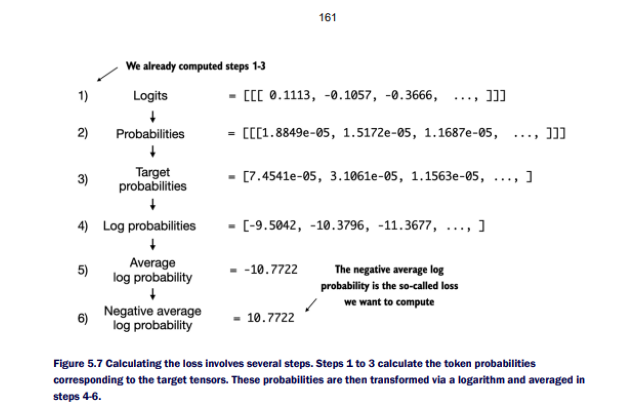

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.7.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### since we already applied steps 1-3 listed in Figure 5.7 to obtain target_probas_1 and target_probas_2, we proceed with step 4, applying the logarithm to the probability scores:

In [22]:
log_probas=torch.log(torch.cat((target_probas_1,target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -10.1492,  -9.7764, -12.2561])


##### working with logarithms of probability scores is more manageable in mathematical optimization than handling the scores directly. This topic is outside the scope of this book,we combine these log probabilities into a single score by computing the average (step 5 in Figure 5.7):


In [23]:
avg_log_probas=torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.5722)


##### The goal is to get the average log probability as close to 0 as possible by updating the model's weights as part of the training process

##### However, in deep learning, the common practice isn't to push the average log probability up to 0 but rather to bring the negative average log probability down to 0. The negative average log probability is simply the average log probability multiplied by -1, which corresponds to step 6 in Figure 5.7:


In [24]:
neg_avg_log_probas= avg_log_probas*-1
print(neg_avg_log_probas)

tensor(10.5722)


##### The term for this negative value, -10.7940 turning into 10.7940, is known as the cross entropy loss in deep learning.


##### pyTorch comes in handy here, as it already has a built-in cross_entropy function that takes care of all these 6 steps in Figure 5.7 for us

##### Before we apply the cross entropy function, briefly recall the shape of the logits andtarget tensors:

In [25]:
print("Logits shape:",logits.shape)
print("targets shape:" ,targets.shape)

Logits shape: torch.Size([2, 3, 50257])
targets shape: torch.Size([2, 3])


##### the logits tensor has three dimensions: batch size, number of tokens, and vocabulary size. The targets tensor has two dimensions: batch size and number of tokens. For the cross entropy_loss function in PyTorch, we want to flatten these tensors by combining them over the batch dimension:

In [26]:
logits_flat=logits.flatten(0,1)
targets_flat=targets.flatten(0,1)

In [27]:
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


##### remember that the targets are the token IDs we want the LLM to generate, and the logits contain the unscaled model outputs before they enter the softmax function to obtain the probability scores

##### previously, we applied the softmax function, selected the probability scores corresponding to the target IDs, and computed the negative average log probabilities. PyTorch's cross_entropy function will take care of all these steps for us

In [28]:
loss=torch.nn.functional.cross_entropy(logits_flat,targets_flat)
print(loss)

tensor(10.5722)


##### till here, we calculated the loss for two small text inputs for illustration purposes. next, we apply the loss computation to the entire training and validation sets.

### 5.1.3 Calculating the training and validation set losses

##### prepare the training and validation datasets ,then calculaate th cross entropy for training and validation sets

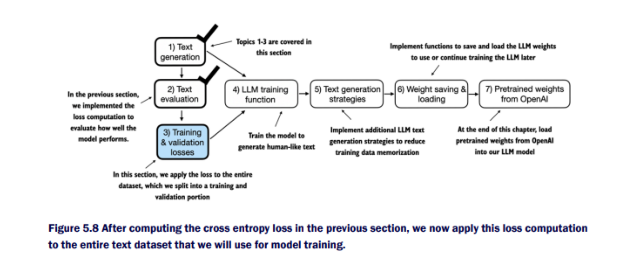

In [29]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.8.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [30]:
file_path="../the-verdict.txt"
with open(file_path,"r",encoding="utf=-8") as file:
    text_data=file.read()

In [31]:
total_characters=len(text_data)
total_tokens=len(tokenizer.encode(text_data))
print("characters",total_characters)
print("tokens:", total_tokens)

characters 20479
tokens: 5145


##### we divide the dataset into a training and a validation set and use the data loaders from chapter 2 to prepare the batches for LLM training

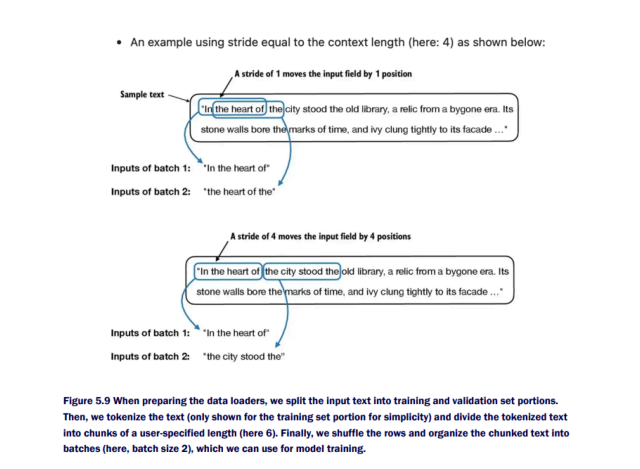

In [32]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.9.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### for visualization purposes, Figure 5.9 uses a max_length=6 due to spatial constraints.However, for the actual data loaders we are implementing, we set the max_length equal to the 256-token context length that the LLM supports so that the LLM sees longer texts during training.


##### To implement the data splitting and loading visualized in Figure 5.9, we first define a train_ratio to use 90% of the data for training and the remaining 10% as validation data for model evaluation during training:

In [33]:
len(text_data)

20479

In [34]:
train_ratio =0.90
split_idx=int(train_ratio * len(text_data)) ## int(0.90 * 20479= 18431.1), so splitting happens at index 18431
train_data= text_data[:split_idx] ## text_data[start:end] ie start from 0 and stop at index 18431
val_data=text_data[split_idx:] ### start from 18431 and stop at end

##### using the train and val data now create the respective data loader reusing the create_dataloader_v1 code from chapter 2:

In [35]:
from components import create_dataloader_v1
torch.manual_seed(123)

train_loader=create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader=create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False, 
    num_workers=0   
)

The above code creates two **DataLoaders**: one for training and one for validation.

- `train_loader` takes `train_data`, tokenizes the text, creates input-target pairs for next-token prediction, groups them into batches, and shuffles the data for training.

- `val_loader` performs the same preprocessing on `val_data`, but does not shuffle because it is only used for model evaluation.

- `max_length` defines the number of tokens in each input sequence, while `stride` controls how far the sliding window moves to create the next sample. Since both are set to the context length, the dataset creates non-overlapping chunks.

After this, the DataLoaders are ready to provide batches of token IDs to the GPT model during training and evaluation. we are basically getting the data ready to feed into the model

##### we used a relatively small batch size in the preceding code to reduce the computational resource demand because we were working with a very small dataset. In practice, training LLMs with batch sizes of 1,024 or larger is not uncommon

##### we can iterate through the data loaders to ensure that they were created correctly:

In [36]:
print("train loader")
for x, y in train_loader:
    print(x.shape, y.shape)

train loader
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])


In [37]:
print("val loader")
for x, y in val_loader:
    print(x.shape, y.shape)

val loader
torch.Size([2, 256]) torch.Size([2, 256])


##### Based on the preceding code output, we have 9 training set batches with 2 samples and 256 tokens each. Since we allocated only 10% of the data for validation, there is only one validation batch consisting of 2 input example

In [38]:
train_tokens=0
for input_batch,output_batch in train_loader:
    train_tokens+=input_batch.numel()
print("total training tokens:" ,train_tokens)

total training tokens: 4608


In [39]:
val_tokens=0
for input_batch,output_batch in val_loader:
    val_tokens+=input_batch.numel()
print("total val tokens:" ,val_tokens)

total val tokens: 512


In [40]:
print("total tokens:", train_tokens + val_tokens)

total tokens: 5120


##### next ,we implement a utility function to calculate the cross entropy loss of a given batch returned via the training and validation loader:

In [41]:
def calc_loss_batch(input_batch,target_batch,model,device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device) #A the transfer to a given device allows us to transfer the data to a GPU
    #dont really have to understand the above line.
    logits=model(input_batch) # make predicion using the inputs , and save it as logits
    loss=torch.nn.functional.cross_entropy(
        logits.flatten(0,1), target_batch.flatten()  #compre the logits ie prediction of the model with actual target to get loss
    )
    return loss

##### use this calc_loss_batch utility function, which computes the loss for a single batch, to implement the following calc_loss_loader function that computes the loss over all the batches sampled by a given data loader

In [42]:
def calc_loss_loader(data_loader,model,device,num_batches=None):
    total_loss=0
    if len(data_loader)==0:
        return float("nan")
    elif num_batches is None:
        num_batches=len(data_loader)
    else:
        num_batches=min(num_batches,len(data_loader))
    for i, (input_batch,target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss=calc_loss_batch(input_batch,target_batch,model,device)
            total_loss+=loss.item()
        else:
            break
    return total_loss/ num_batches

# `calc_loss_loader()` Summary

## Purpose

`calc_loss_loader()` calculates the **average loss of a model over multiple batches** from a DataLoader.

It combines the losses calculated from each individual batch using `calc_loss_batch()`.

---

## Workflow

1. The function receives:
   - DataLoader containing batches of input and target tokens
   - The GPT model
   - The device (CPU/GPU)
   - Optional number of batches to evaluate

2. It initializes `total_loss` to store the accumulated loss from all batches.

3. It checks whether the DataLoader contains any data:
   - If there are no batches, it returns `NaN`.
   - Otherwise, it determines how many batches should be processed.

4. It loops through each batch in the DataLoader.

5. For every batch:
   - The input tokens are passed into the model.
   - The model produces logits (predictions).
   - The logits are compared with the target tokens.
   - The loss for that batch is calculated using `calc_loss_batch()`.

6. Each batch loss is added to `total_loss`.

7. After processing all selected batches:
   - The total loss is divided by the number of batches.
   - The function returns the average loss.

---

#### letsnow see this calc_loss_batch function in action, applying it to the training and validation set loaders:

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #A
model.to(device)
with torch.no_grad():
    train_loss=calc_loss_loader(train_loader,model,device)
    val_loss=calc_loss_loader(val_loader,model,device)
print("training loss",train_loss)
print("val loss",val_loss)

training loss 10.98758347829183
val loss 10.98110580444336


##### the loss values are relatively high because the model has not yet been trained. For comparison, the loss approaches 0 if the model learns to generate the next tokens as they appear in the training and validation sets

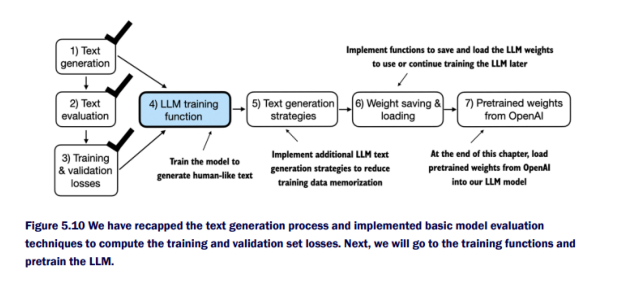

In [44]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.10.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### Now that we have a way to measure the quality of the generated text, in the nextsection, we train the LLM to reduce this loss so that it becomes better at generating tex the next section focuses on pretraining the LLM. After model training, we implement alternative text generation strategies and save and load pretrained model weights.

### 5.2 training an LLM

##### main function for pretraining LLMs

In [45]:
#print(input_batch.numel())

In [46]:
def train_model(model,train_loader,val_loader,optimizer,device,num_epochs,eval_freq,eval_iter,start_context,tokenizer):
    train_losses,val_losses,track_tokens_seen=[],[],[]
    tokens_seen,global_step=0,-1
    
    for epoch in range(num_epochs):
        model.train()
        for input_batch,target_batch in train_loader:
            optimizer.zero_grad()
            loss=calc_loss_batch(input_batch,target_batch,model,device)
            loss.backward()
            optimizer.step()
            tokens_seen = tokens_seen + input_batch.numel()
            global_step +=1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model,train_loader,val_loader,device,eval_iter
                )

                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        generate_and_print_sample(
            model,tokenizer,device,start_context
        )

    return train_losses,val_losses,track_tokens_seen

# `train_model()` — Step-by-Step Explanation

This function trains the GPT model for multiple epochs, periodically evaluates it on the validation set, and generates a sample after each epoch.

---

## Function Definition

```python
def train_model(model, train_loader, val_loader, optimizer, device,
                num_epochs, eval_freq, eval_iter,
                start_context, tokenizer):
```

### Parameters

- **model** – The GPT model to train.
- **train_loader** – DataLoader containing the training data.
- **val_loader** – DataLoader containing the validation data.
- **optimizer** – Updates the model's weights using gradients.
- **device** – CPU or GPU where the model runs.
- **num_epochs** – Number of complete passes through the training dataset.
- **eval_freq** – Evaluate the model every `eval_freq` training steps.
- **eval_iter** – Number of batches used during evaluation.
- **start_context** – Initial text prompt used for sample generation.
- **tokenizer** – Converts generated token IDs back into text.

---

## Initialize Tracking Variables

```python
train_losses, val_losses, track_tokens_seen = [], [], []
tokens_seen, global_step = 0, -1
```

### Purpose

These variables keep track of training progress.

- **train_losses** → Stores training loss values.
- **val_losses** → Stores validation loss values.
- **track_tokens_seen** → Stores how many tokens the model has processed.
- **tokens_seen** → Running total of processed tokens.
- **global_step** → Counts optimization steps.

---

## Epoch Loop

```python
for epoch in range(num_epochs):
```

### Purpose

Runs training for the specified number of epochs.

An epoch means the model has seen the **entire training dataset once**.

---

## Set Model to Training Mode

```python
model.train()
```

### Purpose

Puts the model into training mode.

This enables layers like:

- Dropout
- BatchNorm (if present)

to behave correctly during training.

---

## Iterate Through Training Batches

```python
for input_batch, target_batch in train_loader:
```

### Purpose

Loads one batch at a time.

Each batch contains:

- **input_batch** → Input token IDs
- **target_batch** → Expected next-token IDs

---

## Clear Previous Gradients

```python
optimizer.zero_grad()
```

### Purpose

Removes gradients from the previous iteration.

PyTorch **accumulates gradients by default**, so they must be cleared before each backward pass.

---

## Compute Loss

```python
loss = calc_loss_batch(input_batch, target_batch, model, device)
```

### Purpose

1. Moves data to the correct device.
2. Performs a forward pass.
3. Computes the loss between predictions and targets.

Returns a single loss value.

---

## Backpropagation

```python
loss.backward()
```

### Purpose

Computes gradients of the loss with respect to every trainable parameter.

These gradients are stored in each parameter's `.grad` attribute.

---

## Update Model Parameters

```python
optimizer.step()
```

### Purpose

Uses the computed gradients to update:

- Weights
- Biases

The optimizer changes them slightly to reduce future loss.

---

## Count Processed Tokens

```python
tokens_seen = tokens_seen + input_batch.numel()
```

### Purpose

Counts how many input tokens have been processed.

`input_batch.numel()` returns the total number of elements (tokens) in the batch.

Example:

```
Batch Size = 2
Sequence Length = 256

input_batch.shape = (2, 256)

Tokens processed = 2 × 256 = 512
```

---

## Increment Global Step

```python
global_step += 1
```

### Purpose

Counts how many optimizer updates have occurred.

This is different from epochs.

Example:

```
Epoch 1
 Step 1
 Step 2
 Step 3

Epoch 2
 Step 4
 Step 5
 Step 6
```

---

## Periodic Evaluation

```python
if global_step % eval_freq == 0:
```

### Purpose

Evaluates the model every `eval_freq` training steps.

Example:

```
eval_freq = 100

Evaluation occurs at:

Step 0
Step 100
Step 200
Step 300
...
```

---

## Compute Training and Validation Loss

```python
train_loss, val_loss = evaluate_model(
    model,
    train_loader,
    val_loader,
    device,
    eval_iter
)
```

### Purpose

Measures how well the model performs on:

- Training data
- Validation data

without updating the weights.

---

## Store Metrics

```python
train_losses.append(train_loss)
val_losses.append(val_loss)
track_tokens_seen.append(tokens_seen)
```

### Purpose

Saves values for later visualization.

These lists can be used to plot:

- Training loss curve
- Validation loss curve
- Loss vs. tokens processed

---

## Print Progress

```python
print(
    f"Ep {epoch+1} (Step {global_step:06d}): "
    f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}"
)
```

### Purpose

Displays training progress.

Example:

```
Ep 2 (Step 000300):
Train loss 2.183
Val loss 2.441
```

Formatting:

- `:06d` → Pads the step number with leading zeros.
- `:.3f` → Displays three decimal places.

---

## Generate Sample Text

```python
generate_and_print_sample(
    model,
    tokenizer,
    device,
    start_context
)
```

### Purpose

After each epoch, the model generates text beginning with the provided prompt.

Example:

```
Prompt:

"Every effort moves you"

Generated:

"Every effort moves you closer to your dreams..."
```

This helps monitor qualitative improvements during training.

---

## Return Results

```python
return train_losses, val_losses, track_tokens_seen
```

### Purpose

Returns all recorded metrics for later analysis and plotting.

---

# Overall Training Workflow

```
Start Training
      │
      ▼
Initialize counters
      │
      ▼
For each Epoch
      │
      ▼
model.train()
      │
      ▼
For each Batch
      │
      ▼
Zero Gradients
      │
      ▼
Forward Pass
      │
      ▼
Compute Loss
      │
      ▼
Backward Pass
      │
      ▼
Optimizer Step
      │
      ▼
Update Token Count
      │
      ▼
Increment Step
      │
      ▼
Evaluate Every eval_freq Steps
      │
      ▼
Save Losses
      │
      ▼
Print Progress
      │
      ▼
End of Epoch
      │
      ▼
Generate Sample Text
      │
      ▼
Repeat Until All Epochs Complete
      │
      ▼
Return Recorded Metrics
```

##### note that the train_model_simple function we just created uses two functions we have not defined yet: evaluate_model and generate_and_print_sample.


##### the evaluate_model function calculates the loss over the training and validation set while ensuring the model is in evaluation mode with gradient tracking and dropout disabled when calculating the loss over the training and validation sets:

In [47]:
def evaluate_model(model,train_loader,val_loader,device,eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss=calc_loss_loader(train_loader, model, device,num_batches=eval_iter)
        val_loss=calc_loss_loader(val_loader, model, device,num_batches=eval_iter)
    model.train()
    return train_loss,val_loss

In [48]:
def generate_and_print_sample(model,tokenizer,device,start_context):
    model.eval()
    context_size=model.pos_emb.weight.shape[0]
    encoded=text_to_token_ids(start_context,tokenizer).to(device)
    with torch.no_grad():
        tokens_ids =generate_text_simple(
            model=model,
            input_tokens=encoded,
            max_new_tokens=50,
            context_size=context_size
        )
        decoded_text= token_ids_to_text(tokens_ids,tokenizer)
        print(decoded_text.replace("\n"," "))
    model.train()

In [49]:
torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)
model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004,
    weight_decay=0.1
)

num_epochs = 10  ##NOTE: THE BOOK HAS DONE 10 EPOCHS ONLY. i increased it myself

train_losses, val_losses, tokens_seen = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=1,
    start_context="Every effort moves you",
    tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.897, Val loss 9.933
Ep 1 (Step 000005): Train loss 7.917, Val loss 8.339
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.847, Val loss 7.048
Ep 2 (Step 000015): Train loss 5.997, Val loss 6.616
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Ep 3 (Step 000020): Train loss 5.659, Val loss 6.600
Ep 3 (Step 000025): Train loss 5.363, Val loss 6.348
Every effort moves you, and I had been.                                            
Ep 4 (Step 000030): Train loss 4.010, Val loss 6.278
Ep 4 (Step 000035): Train loss 2.549, Val loss 6.226
Every effort moves you know the                          "I he had the donkey and I had the and I had the donkey and down the room, I had
Ep 5 (Step 000040): Train loss 3.834, Val loss 6.160
Every effort moves you know it was not that the picture--I had the fact by the last

In [50]:
torch.save(model.state_dict(), "gpt_model.pth")

In [51]:
import os
print(os.getcwd())

C:\Users\dipsa\Desktop\LLM-from-scratch\04- Pretraining


In [52]:
import os

print(os.path.exists("gpt_model.pth"))
print(os.path.getsize("gpt_model.pth"), "bytes")

True
652886795 bytes


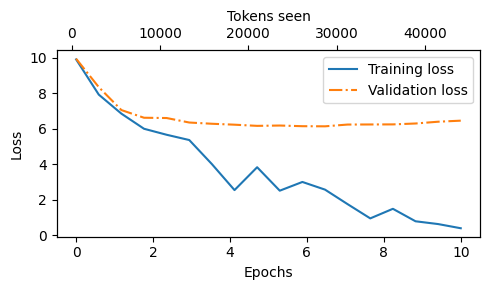

In [53]:
import matplotlib.pyplot as plt
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax2 = ax1.twiny() #A/
    ax2.plot(tokens_seen, train_losses, alpha=0) #B
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)


##### we can see that Training loss: 0.011 and Validation loss: 7.168. the validation loss is much higher than the training loss.This large gap indicates overfitting.

##### the model is overfitted because we also set the numbeer of epoch high for such small dtaset

##### This memorization is expected since we are working with a very, very small training dataset and training the model for multiple epochs. Usually, it's common to train a model on a much, much larger dataset for only one epoch

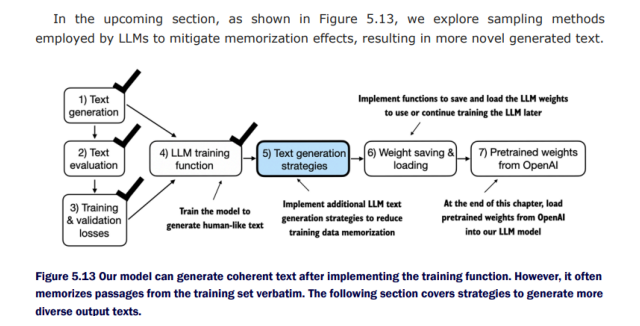

In [54]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.13.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### the next section will cover text generation strategies for LLM to reduce training data memorization and increase the originality of the LLM-generated text before we cover weight loading and saving and loading pretrained weights from OpenAI's GPT model

###  5.3 Decoding strategies to control randomness

##### In this section, we will cover text generation strategies (also called decoding strategies) to generate more original text. First, we briefly revisit the generate_text_simple function from the previous chapter that we used inside the generate_and_print_sample earlier in this chapter. Then, we will cover two techniques, temperature scaling, and top-k sampling, to improve this function.

##### We begin by transferring the model back from the GPU to the CPU since inference with a relatively small model does not require a GPU. Also, after training, we put the model into evaluation model to turn off random components such as dropout:

In [57]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (att): MaskedMultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (output_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (norm2): LayerNorm()
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (dropout_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (att): MaskedMultiHeadAtt

##### Next, we plug the GPTModel instance (model) into the generate_text_simple function,which uses the LLM to generate one token at a time:

In [58]:
tokenizer=tiktoken.get_encoding("gpt2")
token_ids=generate_text_simple(
    model=model,
    input_tokens=text_to_token_ids("Every effort moves you",tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("output text:\n",token_ids_to_text(token_ids,tokenizer))

output text:
 Every effort moves you know," was one of the axioms he laid down across the Sevres and silver of an exquisitely appointed lun


##### The following subsections introduce two concepts to control the randomness and diversity of the generated text: temperature scaling and top-k sampling

### 5.3.1 Temperature scaling

##### temperature scaling, a technique that adds a probabilistic selection process to the next-token generation task.

##### previously, inside the generate_text_simple function, we always sampled the token with the highest probability as the next token using torch.argmax, also known as greedy decoding. To generate text with more variety, we can replace the argmax with a function that samples from a probability distribution (here, the probability scores the LLM generates for each vocabulary entry at each token generation step).

###### To illustrate the probabilistic sampling with a concrete example, let's briefly discuss the next-token generation process using a very small vocabulary for illustration purposes:

In [59]:
vocab = {
"closer": 0,
"every": 1,
"effort": 2,
"forward": 3,
"inches": 4,
"moves": 5,
"pizza": 6,
"toward": 7,
"you": 8,
}

inverse_vocab={v:k for k,v in vocab.items()}

In [60]:
inverse_vocab

{0: 'closer',
 1: 'every',
 2: 'effort',
 3: 'forward',
 4: 'inches',
 5: 'moves',
 6: 'pizza',
 7: 'toward',
 8: 'you'}

##### Next, assume the LLM is given the start context "every effort moves you" and generates the following next-token logits:

In [61]:
next_token_logits=torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])

##### as discussed in previous chapter ,inside the generate_text_simple, we convert the logits into probabilities via the softmax function and obtain the token ID corresponding the generated token via the argmax function, which we can then map back into text via the inverse vocabulary

In [62]:
probas=torch.softmax(next_token_logits,dim=0)
next_tokens_id=torch.argmax(probas).item()
print(inverse_vocab[next_tokens_id])

forward


##### Since the largest logit value, and correspondingly the largest softmax probability score, is in the fourth position (index position 3 since Python uses 0-indexing), the generated word is forward(looking at the inverse_vocab)

##### To implement a probabilistic sampling process, we can now replace the argmax with themultinomial function in PyTorch:

In [63]:
torch.manual_seed(123)
next_token_id= torch.multinomial(probas,num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


##### The printed output is "forward" just like before. What happened? The multinomial function samples the next token proportional to its probability score. In other words, "forward" is still the most likely token and will be selected by multinomial most of the time but not all the time

In [64]:
def print_sample_tokens(probas):
    torch.manual_seed(123)
    sample=[torch.multinomial(probas,num_samples=1).item() for i in range(1_000)]
    sample_ids=torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sample_ids):
        print(f"{freq} x {inverse_vocab[i]}")
print_sample_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


##### As we can see based on the output, the word "forward" is sampled most of the time (582out of 1000 times), but other tokens such as "closer", "inches", and "toward" will also be sampled some of the time. This means that if we replaced the argmax function with the multinomial function inside the generate_and_print_sample function, the LLM would sometimes generate texts such as "every effort moves you toward", "every effort moves you inches", and "every effort moves you closer" instead of "every effortmoves you forward".

##### We can further control the distribution and selection process via a concept called temperature scaling, where temperature scaling is just a fancy description for dividing the logits by a number greater than 0:

In [65]:
def softmax_with_temperature(logits,temperature):
    scaled_logits=logits/temperature
    return torch.softmax(scaled_logits,dim=0)

##### Temperatures greater than 1 result in more uniformly distributed token probabilities, and Temperatures smaller than 1 will result in more confident (sharper or more peaky) distributions. Let's illustrate this by plotting the original probabilities alongside probabilities scaled with different temperature values:


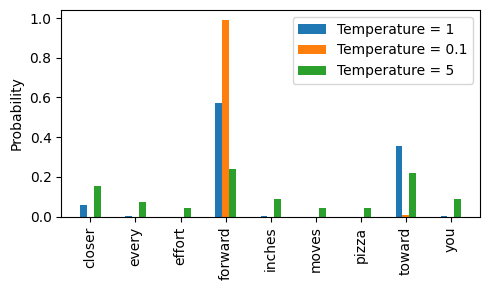

In [66]:
temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
#figure
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(
        x + i * bar_width,
        scaled_probas[i],
        bar_width,
        label=f"Temperature = {T}"
    )
ax.set_ylabel("Probability")
ax.set_xticks(x + bar_width)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

###### Figure 5.14 A temperature of 1 represents the unscaled probability scores for each token in the vocabulary.Decreasing the temperature to 0.1 sharpens the distribution, so the most likely token (here "forward") will have an even higher probability score. Vice versa, increasing the temperature to 5 makes the distribution more uniform.

##### A temperature of 1 divides the logits by 1 before passing them to the softmax function to compute the probability scores. In other words, using a temperature of 1 is the same as not using any temperature scaling. In this case, the tokens are selected with a probability equal to the original softmax probability scores via the multinomial sampling function in PyTorch

##### Also, as we can see in Figure 5.14, applying very small temperatures, such as 0.1, will result in sharper distributions such that the behavior of the multinomial function selectsthe most likely token (here: "forward") almost 100% of the time, approaching the behavior of the argmax function. Vice versa, a temperature of 5 results in a more uniform distribution where other tokens are selected more often. This can add more variety to the generated texts but also more often results in nonsensical text. For example, using the temperature of 5 results in texts such as "every effort moves you pizza" about 4% of the time.


### Top-k sampling

##### in the previous section, we implemented a probabilistic sampling approach coupled with temperature scaling to increase the diversity of the outputs. We saw that higher temperature values result in more uniformly distributed next-token probabilities, which result in more diverse outputs as it reduces the likelihood of the model repeatedly selecting the most probable token

#####  However, One downside of this approach is that it sometimes leads to grammatically incorrect or completely nonsensical outputs such as "every effort moves you pizza".

##### in this section, we introduce another concept called top-k sampling, which, when combined with probabilistic sampling and temperature scaling, can improve the text generation results.

###### In top-k sampling, we can restrict the sampled tokens to the top-k most likely tokens and exclude all other tokens from the selection process by masking their probability scores, as illustrated in Figure 5.15

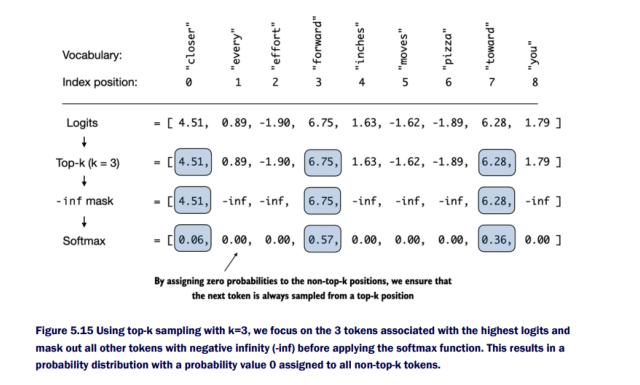

In [67]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("5.15.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### The approach outlined in Figure 5.15 replaces all non-selected logits with negative infinity value (-inf), such that when computing the softmax values, the probability scores of the non-top-k tokens are 0, and the remaining probabilities sum up to 1. 

In [68]:
top_k= 3
top_logits,top_pos= torch.topk(next_token_logits,top_k)
print("top logits:",top_logits)
print("top positions:",top_pos)

top logits: tensor([6.7500, 6.2800, 4.5100])
top positions: tensor([3, 7, 0])


##### Subsequently, we apply PyTorch's where function to set the logit values of tokens that are below the lowest logit value within our top-3 selection to negative infinity (-inf).

In [69]:
new_logits=torch.where(
    condition=next_token_logits <top_logits[-1],
    input=torch.tensor(float('-inf')),
    other=next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


###### Lastly, let's apply the softmax function to turn these into next-token probabilities:

In [70]:
topk_probas=torch.softmax(new_logits,dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


##### We can now apply the temperature scaling and multinomial function for probabilistic sampling introduced in the previous section to select the next token among these 3 nonzero probability scores to generate the next token.We do this in the next section bymodifying the text generation function.


### 5.3.3 Modifying the text generation function

###### The previous two subsections introduced two concepts to increase the diversity of LLMgenerated text: temperature sampling and top-k sampling. In this section, we combine and add these concepts to modify the generate_simple function we used to generate text via the LLM earlier, creating a new generate function:

In [71]:
def generate(model, input_tokens, max_new_tokens, context_size,
             temperature=1.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        input_tokens = input_tokens[:, -context_size:]
        with torch.no_grad():
            logits = model(input_tokens)
        logits = logits[:, -1, :]
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1].unsqueeze(-1)
            logits = torch.where(
                logits < min_val,
                torch.tensor(float("-inf")).to(logits.device),
                logits
            )
        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if eos_id is not None and idx_next.item() == eos_id:
            break
        input_tokens = torch.cat((input_tokens, idx_next), dim=1)
    return input_tokens

##### Let's now see this new generate function in action:

In [72]:
torch.manual_seed(123)
token_ids=generate(
    model=model,
    input_tokens=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)
print("output text:\n",token_ids_to_text(token_ids,tokenizer))

output text:
 Every effort moves you stand to work on surprise, a one of us had gone with random-


### 5.4 - Loading and saving model weights in PyTorch

##### saving a PyTorch model is relatively straightforward. The recommended way is to save a model's so-called state_dict, a dictionary mapping each layer to its parameters, using the torch.save function as follows:

In [76]:
torch.save(model.state_dict(),"model.pth")

In [77]:
model=GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth"))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (att): MaskedMultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (output_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (norm2): LayerNorm()
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (dropout_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (att): MaskedMultiHeadAtt

In [79]:
torch.save({
    "model_state_dict": model.state_dict(),
     "optimizer_state_dict": optimizer.state_dict(),
      },
    "model_and_optimizer.pth"
)

In [80]:
checkpoint=torch.load("model_and_optimizer.pth")
model=GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer=torch.optim.AdamW(model.parameters(),lr=5e-4,weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

# 5.4 Loading Weights in PyTorch

This section covers how to **save** and **load** a trained model in PyTorch. There are two common approaches:

1. Save only the model weights.
2. Save both the model and optimizer state (checkpoint).

---

## 1. Save Only the Model Weights

```python
torch.save(model.state_dict(), "model.pth")
```

### Explanation
- `model.state_dict()` returns a dictionary containing all the model's learned parameters (weights and biases).
- `torch.save()` writes this dictionary to a file named `model.pth`.
- Use this when you only need the trained model for inference or deployment.

---

## 2. Recreate the Model Architecture

```python
model = GPTModel(GPT_CONFIG_124M)
```

### Explanation
- Creates a new instance of the GPT model.
- At this point, the model contains **randomly initialized weights**.
- The architecture **must match** the one used when saving the weights.

---

## 3. Load the Saved Weights

```python
model.load_state_dict(torch.load("model.pth"))
```

### Explanation
- `torch.load()` reads the saved weight dictionary from disk.
- `load_state_dict()` copies those weights into the newly created model.
- The model now has the exact learned parameters from training.

---

## 4. Switch to Evaluation Mode

```python
model.eval()
```

### Explanation
- Puts the model into **evaluation mode**.
- Disables training-specific behaviors such as **Dropout**.
- Use this before generating text or making predictions.

---

# Saving a Training Checkpoint

Instead of saving only the model, you can also save the optimizer state.

```python
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
}, "model_and_optimizer.pth")
```

### Explanation
- Saves a Python dictionary containing:
  - Model weights
  - Optimizer state (AdamW momentum, running averages, etc.)
- This allows training to resume from where it stopped.

---

# Load the Checkpoint

```python
checkpoint = torch.load("model_and_optimizer.pth")
```

### Explanation
- Loads the checkpoint dictionary from disk.
- The dictionary contains both the model state and optimizer state.

---

## Recreate the Model

```python
model = GPTModel(GPT_CONFIG_124M)
```

### Explanation
- Creates a new GPT model with random weights.
- The architecture must be identical to the saved model.

---

## Restore the Model Weights

```python
model.load_state_dict(checkpoint["model_state_dict"])
```

### Explanation
- Retrieves the saved model weights from the checkpoint.
- Loads them into the newly created model.

---

## Create a New Optimizer

```python
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=0.1
)
```

### Explanation
- Creates a new AdamW optimizer.
- It must exist before its saved state can be restored.

---

## Restore the Optimizer State

```python
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
```

### Explanation
- Restores the optimizer's internal state.
- Preserves momentum, running averages, and training progress.
- Allows training to continue smoothly instead of restarting optimization.

---

## Switch Back to Training Mode

```python
model.train()
```

### Explanation
- Puts the model back into **training mode**.
- Enables Dropout and other training-specific layers.
- Call this before continuing training.

---

# Summary

| Code | Purpose |
|------|---------|
| `model.state_dict()` | Returns the model's learned weights. |
| `optimizer.state_dict()` | Returns the optimizer's internal state. |
| `torch.save()` | Saves data to a file. |
| `torch.load()` | Loads saved data from a file. |
| `load_state_dict()` | Restores weights or optimizer state into an existing object. |
| `model.eval()` | Sets the model to inference mode. |
| `model.train()` | Sets the model to training mode. |

---

## Workflow

```text
Train Model
     │
     ▼
Save model.state_dict()
     │
     ▼
model.pth
     │
     ▼
Create new model
     │
     ▼
Load weights
     │
     ▼
Inference (model.eval())


OR


Train Model
      │
      ▼
Save model + optimizer
      │
      ▼
checkpoint.pth
      │
      ▼
Load checkpoint
      │
      ├── Restore model weights
      └── Restore optimizer state
      │
      ▼
Continue training (model.train())
```